In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings ("ignore")

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df_sales = pd.read_csv ("FACT_SALES (1).csv")
df_category = pd.read_csv ("DIM_CATEGORY (2).csv")
df_product = pd.read_excel ("DIM_PRODUCT (1).xlsx")
df_segment = pd.read_excel ("DIM_SEGMENT (1).xlsx")
df_calendar = pd.read_excel ("DIM_CALENDAR (2).xlsx")

In [3]:
display (df_sales.head(), print ("ventas")) 
display (df_category.head(), print ("categorias"))
display (df_product.head(), print ("producto"))
display (df_segment.head(), print ("segmento"))
display (df_calendar.head(),print ("calendario"))

ventas


,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5


None

categorias


,ID_CATEGORY,CATEGORY
0,1,FABRIC TREATMENT and SANIT\r\n
1,2,AIR CARE
2,3,LAVAVAJILLAS
3,4,MEGA SUPERFICIES
4,5,LAVATORY CARE & BRC


...

,CATEGORY,ATTR1,ATTR2,ATTR3,FORMAT,SEGMENT
0,1,CLORO,CLORO,BAMBINO,LIQUIDO,BLEACH
1,1,CLORO,CLORO,GERMICIDA,LIQUIDO,BLEACH
2,1,CLORO,CLORO,MASCOTAS,LIQUIDO,BLEACH
3,1,CLORO,CLORO,MULTIUSOS,GEL,BLEACH
4,1,CLORO,CLORO,MULTIUSOS,LIQUIDO,BLEACH


None

calendario


,WEEK,YEAR,MONTH,WEEK_NUMBER,DATE
0,01-21,2021,1,1,2021-01-10
1,02-21,2021,1,2,2021-01-17
2,03-21,2021,1,3,2021-01-24
3,04-21,2021,1,4,2021-01-31
4,05-21,2021,2,5,2021-02-07


None

In [4]:
df_sales ["ITEM_CODE"] = df_sales ["ITEM_CODE"].astype (str)
df_product ["ITEM"] = df_product ["ITEM"].astype (str)

df_product ["ITEM_KEY"] = df_product ["ITEM"].str.lstrip ("0")

df_sales ["ITEM_KEY"] = df_sales ["ITEM_CODE"].str.replace (r"/D", "", regex = True)

sales_keys = set (df_sales ["ITEM_KEY"].unique ())
product_keys = set (df_product ["ITEM_KEY"].unique ())

print ("Coincidencias:", len (sales_keys & product_keys))
print ("Unicos en sales:", len (sales_keys))
print ("Unicos en product:", len (product_keys))

Coincidencias: 315
Unicos en sales: 350
Unicos en product: 504


In [5]:
df_full = pd.merge (
    df_sales,
    df_product,
    on = "ITEM_KEY",
    how = "left"
)

print (df_sales.shape)
print (df_full.shape)


df_full = pd.merge (
    df_full,
    df_category,
    left_on = "CATEGORY",
    right_on = "ID_CATEGORY",
    how = "left"
)

df_full = pd.merge (
    df_full, 
    df_calendar,
    on = "WEEK",
    how = "left"
)

df_full = df_full.loc [:, ~df_full.columns.duplicated ()]

df_full.info ()

(122002, 7)
(122002, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122002 entries, 0 to 122001
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   WEEK                         122002 non-null  object        
 1   ITEM_CODE                    122002 non-null  object        
 2   TOTAL_UNIT_SALES             122002 non-null  float64       
 3   TOTAL_VALUE_SALES            122002 non-null  float64       
 4   TOTAL_UNIT_AVG_WEEKLY_SALES  122002 non-null  float64       
 5   REGION                       122002 non-null  object        
 6   ITEM_KEY                     122002 non-null  object        
 7   MANUFACTURER                 113479 non-null  object        
 8   BRAND                        113479 non-null  object        
 9   ITEM                         113479 non-null  object        
 10  ITEM_DESCRIPTION             113479 non-null  object        
 11  C

In [6]:
df_full.head ()

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,ITEM_KEY,MANUFACTURER,BRAND,ITEM,...,FORMAT,ATTR1,ATTR2,ATTR3,ID_CATEGORY,CATEGORY_y,YEAR,MONTH,WEEK_NUMBER,DATE
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,7501058792808BP2,RECKITT,VANISH,7501058792808BP2,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1.0,FABRIC TREATMENT and SANIT\r\n,2022,8,34,2022-08-28
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,7501058715883,RECKITT,VANISH,7501058715883,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1.0,FABRIC TREATMENT and SANIT\r\n,2022,8,34,2022-08-28
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,7702626213774,RECKITT,VANISH,7702626213774,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1.0,FABRIC TREATMENT and SANIT\r\n,2022,8,34,2022-08-28
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5,7501058716422,RECKITT,VANISH,7501058716422,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1.0,FABRIC TREATMENT and SANIT\r\n,2022,8,34,2022-08-28
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5,7501058784353,RECKITT,VANISH,7501058784353,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1.0,FABRIC TREATMENT and SANIT\r\n,2022,8,34,2022-08-28


In [7]:
cols_to_drop = [
    "ITEM_CODE",
    "ITEM",
    "ITEM_KEY",
    "ITEM_DESCRIPTION",
    "MANUFACTURER",
    "BRAND",
    "WEEK",
    "DATE",
    "YEAR",
    "MONTH",
    "WEEK_NUMBER",
    "ID_CATEGORY",
    "CATEGORY_x",
    "CATEGORY_y",
    "REGION",
    "FORMAT",
    "ATTR1",
    "ATTR2",
    "ATTR3"
]

df_cluster = df_full.drop (columns = cols_to_drop)
df_cluster.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122002 entries, 0 to 122001
Data columns (total 3 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   TOTAL_UNIT_SALES             122002 non-null  float64
 1   TOTAL_VALUE_SALES            122002 non-null  float64
 2   TOTAL_UNIT_AVG_WEEKLY_SALES  122002 non-null  float64
dtypes: float64(3)
memory usage: 2.8 MB


In [8]:
df_cluster.head ()

,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES
0,0.006,0.139,1.000
1,0.487,116.519,2.916
2,1.391,68.453,5.171
3,0.022,1.481,1.833
4,2.037,182.839,5.375


In [9]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform (df_cluster)

x_scaled = pd.DataFrame (
    x_scaled,
    columns = df_cluster.columns,
    index = df_cluster.index
)

x_scaled.head()

,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES
0,-0.221103,-0.258040,-0.401761
1,-0.187921,0.074251,-0.317169
2,-0.125559,-0.062988,-0.217611
3,-0.219999,-0.254209,-0.364984
4,-0.080995,0.263609,-0.208605


<function matplotlib.pyplot.show(close=None, block=None)>

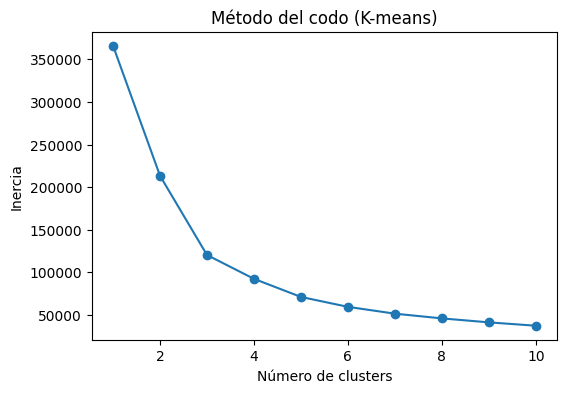

In [10]:
inercias = []
k_range = range (1,11)

for k in k_range:
    kmeans = KMeans (
        n_clusters = k,
        random_state = 137,
        n_init = 10
    )
    kmeans.fit (x_scaled)
    inercias.append (kmeans.inertia_)

plt.figure (figsize = (6,4))
plt.plot (k_range, inercias, marker = "o")
plt.xlabel ("Número de clusters")
plt.ylabel ("Inercia")
plt.title ("Método del codo (K-means)")
plt.show

In [11]:
kmeans = KMeans(
    n_clusters = 3,
    random_state = 137,
    n_init = 10
)

clusters= kmeans.fit_predict (x_scaled)

df_full ["cluster"] = clusters
df_full ["cluster"].value_counts().sort_index()

cluster
0    118200
1       260
2      3542
Name: count, dtype: int64

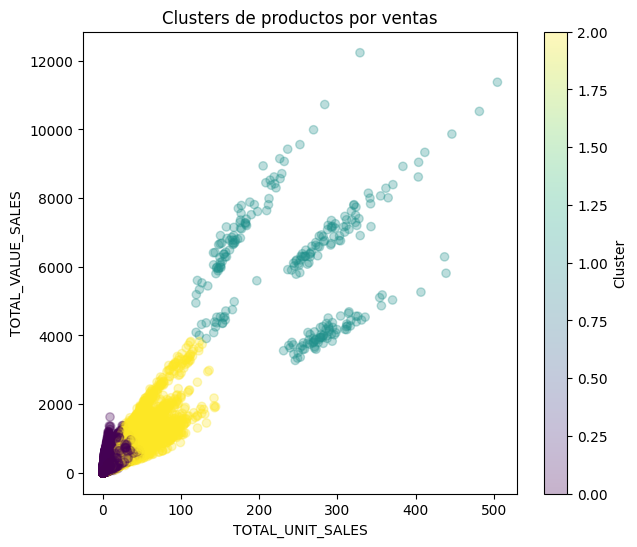

In [12]:
plt.figure (figsize = (7,6))
plt.scatter (
    df_full ["TOTAL_UNIT_SALES"],
    df_full ["TOTAL_VALUE_SALES"],
    c = df_full ["cluster"],
    alpha = 0.3
)

plt.xlabel ("TOTAL_UNIT_SALES")
plt.ylabel ("TOTAL_VALUE_SALES")
plt.title ("Clusters de productos por ventas")
plt.colorbar (label = "Cluster")
plt.show ()

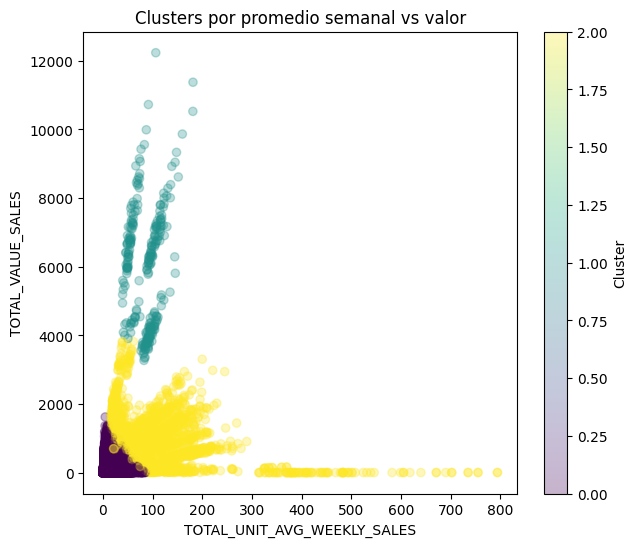

In [13]:
plt.figure (figsize = (7,6))
plt.scatter (
    df_full ["TOTAL_UNIT_AVG_WEEKLY_SALES"],
    df_full ["TOTAL_VALUE_SALES"],
    c = df_full ["cluster"],
    alpha = 0.3
)

plt.xlabel ("TOTAL_UNIT_AVG_WEEKLY_SALES")
plt.ylabel ("TOTAL_VALUE_SALES")
plt.title ("Clusters por promedio semanal vs valor")
plt.colorbar (label = "Cluster")
plt.show ()

In [14]:
df_full.groupby("cluster")[[
    "TOTAL_UNIT_SALES",
    "TOTAL_VALUE_SALES",
    "TOTAL_UNIT_AVG_WEEKLY_SALES"
]].mean()

,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES
cluster,,,
0,1.630981,54.479386,7.323602
1,248.404358,6005.599069,86.388423
2,37.942725,858.820092,97.147879


In [15]:
df_full ["cluster"].value_counts (normalize = True)

cluster
0    0.968837
2    0.029032
1    0.002131
Name: proportion, dtype: float64

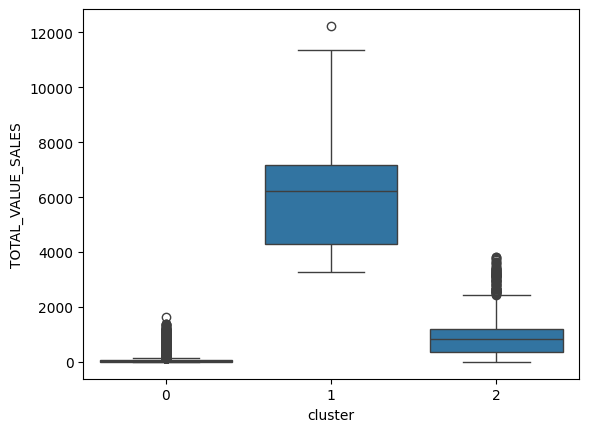

In [16]:
sns.boxplot (data = df_full, x ="cluster", y = "TOTAL_VALUE_SALES")
plt.show ()

In [17]:
cluster_category = (
    df_full
    .groupby (["cluster", "CATEGORY_y"])
    .size ()
    .reset_index (name = "count")
)

cluster_category

,cluster,CATEGORY_y,count
0,0,FABRIC TREATMENT and SANIT\r\n,111367
1,1,FABRIC TREATMENT and SANIT\r\n,20
2,2,FABRIC TREATMENT and SANIT\r\n,2092


In [18]:
cluster_region = (
    df_full
    .groupby (["cluster", "REGION"])
    .size ()
    .reset_index (name = "count")
)

cluster_region_pct = (
    cluster_region
    .groupby ("cluster")
    .apply (lambda x: x.assign (pct = x["count"]/x ["count"].sum ())).reset_index (drop = True)
           )

cluster_region_pct.sort_values (["cluster", "pct"], ascending = [True, False])

,cluster,REGION,count,pct
6,0,TOTAL AUTOS SCANNING MEXICO,19605,0.165863
1,0,TOTAL AUTOS AREA 2,18074,0.152910
3,0,TOTAL AUTOS AREA 4,16837,0.142445
5,0,TOTAL AUTOS AREA 6,16398,0.138731
2,0,TOTAL AUTOS AREA 3,16142,0.136565
4,0,TOTAL AUTOS AREA 5,15668,0.132555
0,0,TOTAL AUTOS AREA 1,15476,0.130931
7,1,TOTAL AUTOS SCANNING MEXICO,260,1.000000
14,2,TOTAL AUTOS SCANNING MEXICO,1125,0.317617
13,2,TOTAL AUTOS AREA 6,515,0.145398


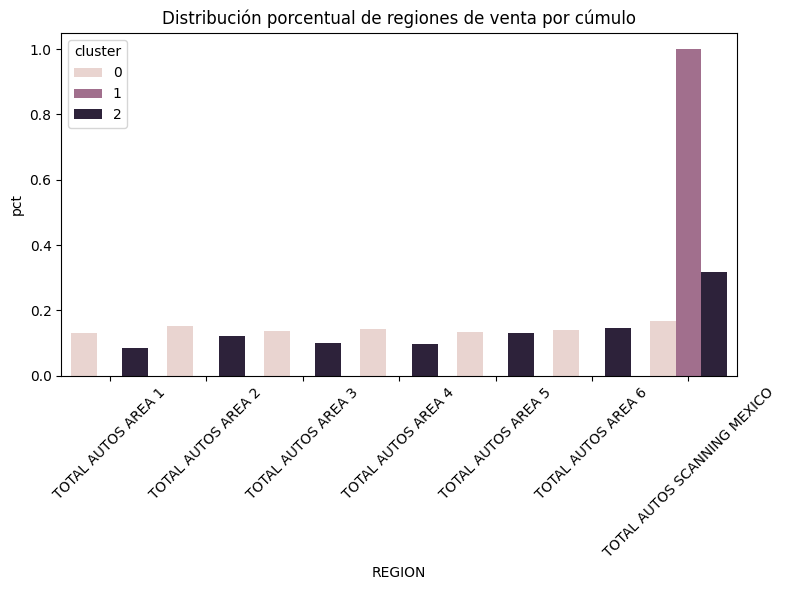

In [19]:
plt.figure (figsize = (8,6))

sns.barplot(
    data = cluster_region_pct,
    x = "REGION",
    y = "pct",
    hue = "cluster"
)

plt.xticks (rotation = 45)
plt.title ("Distribución porcentual de regiones de venta por cúmulo")
plt.tight_layout()
plt.show()

In [20]:
format_by_cluster = (
    df_full
    .groupby (["cluster", "FORMAT"])
    .size ()
    .reset_index (name = "count")
)

format_by_cluster_pct = (
    format_by_cluster
    .groupby ("cluster")
    .apply (lambda x: x.assign (pct = x["count"]/x ["count"].sum ())).reset_index (drop = True)
           )

format_by_cluster_pct.sort_values (["cluster", "pct"], ascending = [True, False])

,cluster,FORMAT,count,pct
2,0,LIQUIDO,62133,0.557912
1,0,GEL,24595,0.220846
3,0,POLVO,20521,0.184265
0,0,BARRA,3558,0.031948
4,0,TOALLAS,560,0.005028
5,1,LIQUIDO,20,1.000000
8,2,LIQUIDO,1444,0.690249
7,2,GEL,567,0.271033
6,2,BARRA,81,0.038719


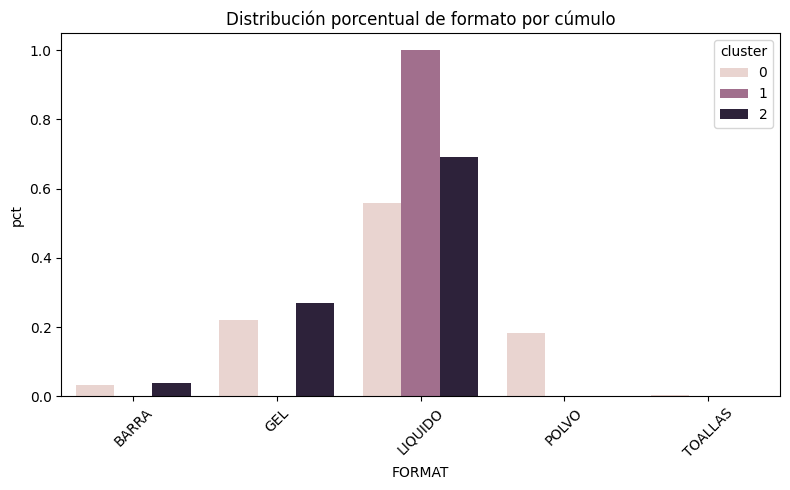

In [21]:
plt.figure (figsize = (8,5))

sns.barplot(
    data = format_by_cluster_pct,
    x = "FORMAT",
    y = "pct",
    hue = "cluster"
)

plt.xticks (rotation = 45)
plt.title ("Distribución porcentual de formato por cúmulo")
plt.tight_layout()
plt.show()

In [22]:
attr3_cluster = (
    df_full
    .groupby (["cluster", "ATTR3"])
    .size ()
    .reset_index (name = "count")
)

attr3_cluster_pct = (
    attr3_cluster
    .groupby ("cluster")
    .apply (lambda x: x.assign (pct = x["count"]/x ["count"].sum ())).reset_index (drop = True)
           )

attr3_cluster_pct.sort_values (["cluster", "pct"], ascending = [True, False])

,cluster,ATTR3,count,pct
4,0,PRE LAVADOR,28751,0.258164
3,0,NO DEFINIDO,26696,0.239712
6,0,ROSA,16269,0.146085
0,0,BLANCO,15768,0.141586
2,0,MULTIUSOS,13291,0.119344
1,0,MASCOTAS,5569,0.050006
7,0,SANITIZANTE,5019,0.045067
5,0,ROPA BEBE,4,0.000036
8,1,NO DEFINIDO,20,1.000000
12,2,NO DEFINIDO,1432,0.684512


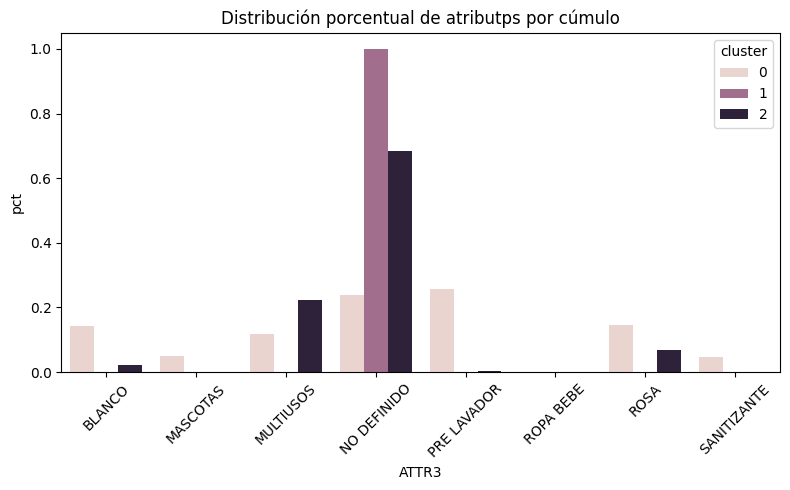

In [23]:
plt.figure (figsize = (8,5))

sns.barplot(
    data = attr3_cluster_pct,
    x = "ATTR3",
    y = "pct",
    hue = "cluster"
)

plt.xticks (rotation = 45)
plt.title ("Distribución porcentual de atributps por cúmulo")
plt.tight_layout()
plt.show()

In [24]:
cluster_manufacturer = (
    df_full
    .groupby (["cluster", "MANUFACTURER"])
    .size ()
    .reset_index (name = "count")
)

cluster_manufacturer_pct = (
    cluster_manufacturer
    .groupby ("cluster")
    .apply (lambda x: x.assign (pct = x["count"]/x ["count"].sum ())).reset_index (drop = True)
           )

cluster_manufacturer_pct.sort_values (["cluster", "pct"], ascending = [True, False])

,cluster,MANUFACTURER,count,pct
13,0,RECKITT,31635,0.284061
6,0,INDS. ALEN,21489,0.192957
2,0,CLOROX,19526,0.175330
3,0,DELTA PRONATURA,11434,0.102670
8,0,JABONERA LA ESPUMA,9828,0.088249
1,0,CHURCH & DWIGHT,5677,0.050976
0,0,BLANQUEADORA MEXICANA,3397,0.030503
5,0,IBERIA,2052,0.018426
11,0,OTHERS FABRICANTE UNIF.,1925,0.017285
4,0,GRUPO AC MARCAS,1680,0.015085


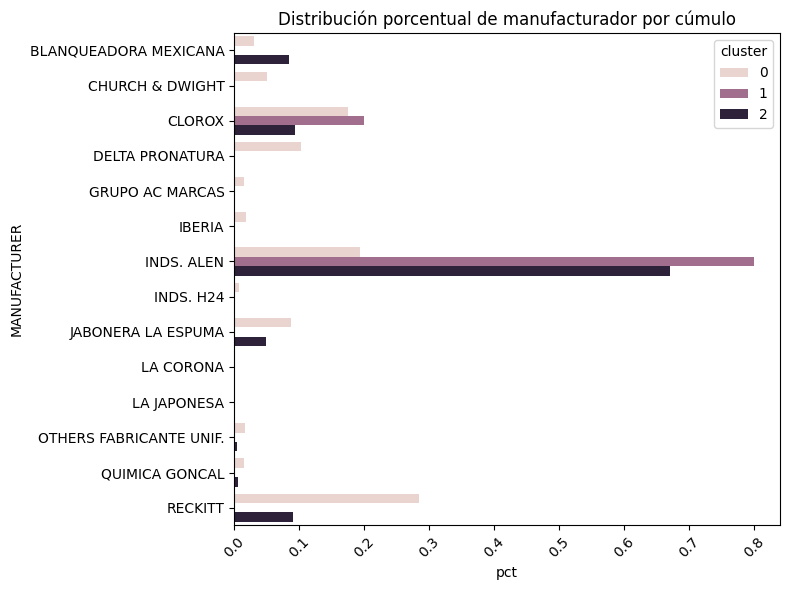

In [25]:
top_manufacturers = (
    cluster_manufacturer_pct
        .groupby ("MANUFACTURER")["count"]
        .sum()
        .sort_values(ascending = False)
        .head (8)
        .index
)

filtered_data = cluster_manufacturer_pct[
    cluster_manufacturer_pct ["MANUFACTURER"].isin (top_manufacturers)
    ]
    

plt.figure (figsize = (8,6))

sns.barplot(
    data = cluster_manufacturer_pct,
    y = "MANUFACTURER",
    x = "pct",
    hue = "cluster"
)

plt.xticks (rotation = 45)
plt.title ("Distribución porcentual de manufacturador por cúmulo")
plt.tight_layout()
plt.show()

In [26]:
df_vanish = df_full [df_full["BRAND"] == "VANISH"]
df_vanish.head ()

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,ITEM_KEY,MANUFACTURER,BRAND,ITEM,...,ATTR1,ATTR2,ATTR3,ID_CATEGORY,CATEGORY_y,YEAR,MONTH,WEEK_NUMBER,DATE,cluster
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,7501058792808BP2,RECKITT,VANISH,7501058792808BP2,...,SAFE BLEACH,FABRIC TREATMENT,ROSA,1.0,FABRIC TREATMENT and SANIT\r\n,2022,8,34,2022-08-28,0
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,7501058715883,RECKITT,VANISH,7501058715883,...,SAFE BLEACH,FABRIC TREATMENT,ROSA,1.0,FABRIC TREATMENT and SANIT\r\n,2022,8,34,2022-08-28,0
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,7702626213774,RECKITT,VANISH,7702626213774,...,SAFE BLEACH,FABRIC TREATMENT,ROSA,1.0,FABRIC TREATMENT and SANIT\r\n,2022,8,34,2022-08-28,0
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5,7501058716422,RECKITT,VANISH,7501058716422,...,SAFE BLEACH,FABRIC TREATMENT,ROSA,1.0,FABRIC TREATMENT and SANIT\r\n,2022,8,34,2022-08-28,0
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5,7501058784353,RECKITT,VANISH,7501058784353,...,SAFE BLEACH,FABRIC TREATMENT,ROSA,1.0,FABRIC TREATMENT and SANIT\r\n,2022,8,34,2022-08-28,0


In [27]:
df_vanish ["cluster"].value_counts (normalize = True)

cluster
0    0.99334
2    0.00666
Name: proportion, dtype: float64

In [28]:
region_total = (
    df_full
    .groupby ("REGION")["TOTAL_VALUE_SALES"]
    .sum()
    .reset_index (name = "total_sales")
)

region_vanish = (
    df_vanish
    .groupby ("REGION")["TOTAL_VALUE_SALES"]
    .sum()
    .reset_index (name = "vanish_sales")
)

region_compare = region_total.merge (region_vanish, on = "REGION", how ="left").fillna (0)

region_compare ["vanish_share"] = (
    region_compare ["vanish_sales"]/ region_compare["total_sales"]
)

region_compare

,REGION,total_sales,vanish_sales,vanish_share
0,TOTAL AUTOS AREA 1,714249.979,112386.932,0.157350
1,TOTAL AUTOS AREA 2,1188796.150,207487.351,0.174536
2,TOTAL AUTOS AREA 3,803655.337,174925.752,0.217663
3,TOTAL AUTOS AREA 4,677435.998,134621.677,0.198722
4,TOTAL AUTOS AREA 5,1153335.538,309934.977,0.268729
5,TOTAL AUTOS AREA 6,983957.571,144788.168,0.147149
6,TOTAL AUTOS SCANNING MEXICO,5521429.320,1084144.668,0.196352


<function matplotlib.pyplot.show(close=None, block=None)>

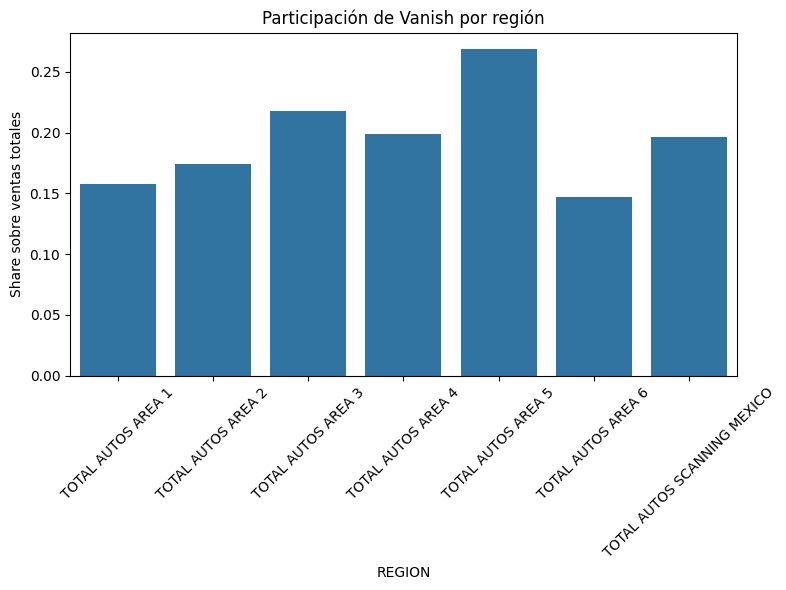

In [29]:
plt.figure (figsize=(8,6))

sns.barplot (
    data = region_compare,
    x = "REGION",
    y = "vanish_share"
)

plt.xticks (rotation = 45)
plt.title ("Participación de Vanish por región")
plt.ylabel ("Share sobre ventas totales")
plt.tight_layout ()
plt.show

In [30]:
format_total = (
    df_full
    .groupby ("FORMAT")["TOTAL_VALUE_SALES"]
    .sum()
    .reset_index (name = "total_sales")
)

format_vanish = (
    df_vanish
    .groupby ("FORMAT")["TOTAL_VALUE_SALES"]
    .sum()
    .reset_index (name = "vanish_sales")
)

format_compare = format_total.merge (format_vanish, on = "FORMAT", how ="left").fillna (0)

format_compare ["vanish_share"] = (
    format_compare ["vanish_sales"]/ format_compare["total_sales"]
)

format_compare

,FORMAT,total_sales,vanish_sales,vanish_share
0,BARRA,243539.230,231055.619,0.948741
1,GEL,2194660.365,509869.610,0.232323
2,LIQUIDO,4364031.269,717986.409,0.164524
3,POLVO,1108091.132,709377.887,0.640180
4,TOALLAS,15041.415,0.000,0.000000


<function matplotlib.pyplot.show(close=None, block=None)>

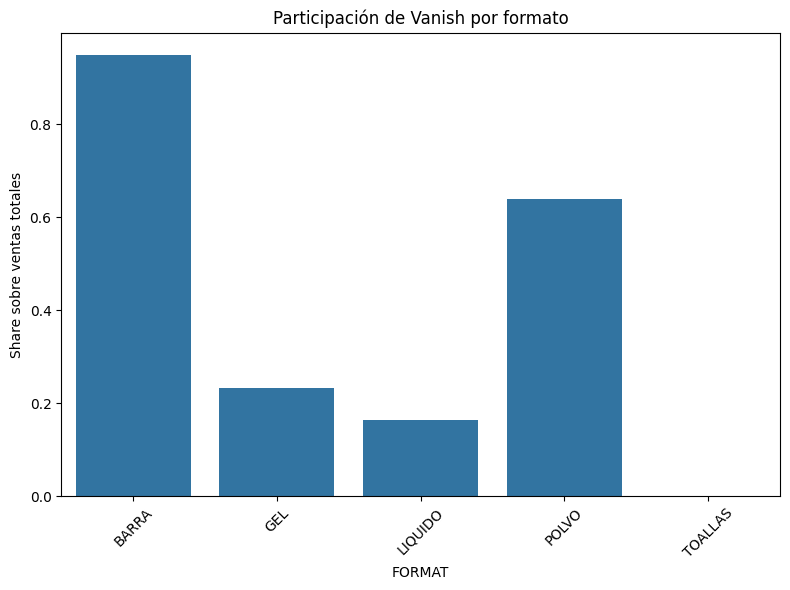

In [31]:
plt.figure (figsize=(8,6))

sns.barplot (
    data = format_compare,
    x = "FORMAT",
    y = "vanish_share"
)

plt.xticks (rotation = 45)
plt.title ("Participación de Vanish por formato")
plt.ylabel ("Share sobre ventas totales")
plt.tight_layout ()
plt.show

In [32]:
attributes_total = (
    df_full
    .groupby ("ATTR3")["TOTAL_VALUE_SALES"]
    .sum()
    .reset_index (name = "total_sales")
)

attributes_vanish = (
    df_vanish
    .groupby ("ATTR3")["TOTAL_VALUE_SALES"]
    .sum()
    .reset_index (name = "vanish_sales")
)

attributes_compare = attributes_total.merge (attributes_vanish, on = "ATTR3", how ="left").fillna (0)

attributes_compare ["vanish_share"] = (
    attributes_compare ["vanish_sales"]/ attributes_compare["total_sales"]
)

attributes_compare

,ATTR3,total_sales,vanish_sales,vanish_share
0,BLANCO,987106.003,902515.060,0.914304
1,MASCOTAS,378309.864,0.000,0.000000
2,MULTIUSOS,1501463.383,0.000,0.000000
3,NO DEFINIDO,2600883.104,0.000,0.000000
4,PRE LAVADOR,1109911.281,0.000,0.000000
5,ROPA BEBE,0.090,0.000,0.000000
6,ROSA,1265774.465,1265774.465,1.000000
7,SANITIZANTE,81915.221,0.000,0.000000


<function matplotlib.pyplot.show(close=None, block=None)>

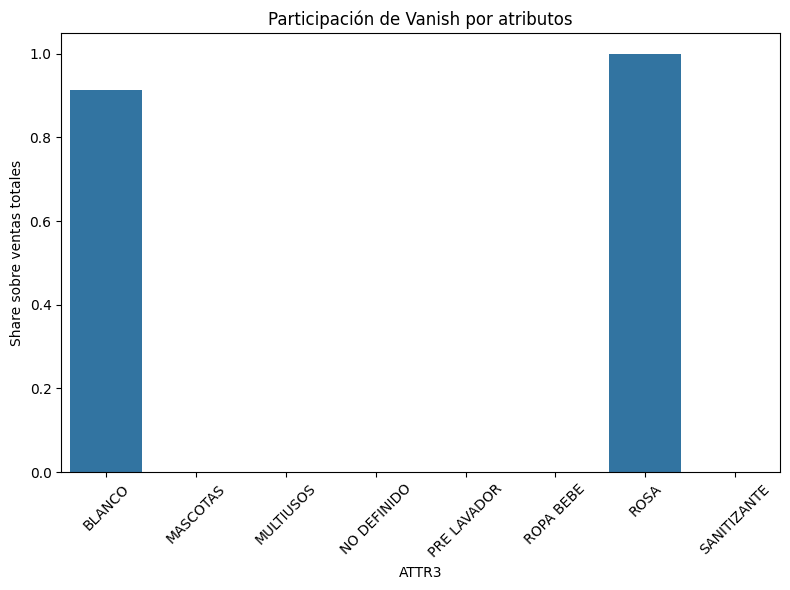

In [33]:
plt.figure (figsize=(8,6))

sns.barplot (
    data = attributes_compare,
    x = "ATTR3",
    y = "vanish_share"
)

plt.xticks (rotation = 45)
plt.title ("Participación de Vanish por atributos")
plt.ylabel ("Share sobre ventas totales")
plt.tight_layout ()
plt.show